# Nutritional Products Sales Breakdown

## Table of Contents <a id='back'></a>
- [Project Introduction](#project-introduction)
    - [Analysis Outline](#analysis-outline)
    - [Executive Summary](#executive-summary)
- [Importing Libraries and Opening Data Files](#importing-libraries-and-opening-data-files)
- [Data Wrangling](#data-wrangling)
    - [Duplicates](#duplicates)
    - [Missing Values](#missing-values)
    - [Data Transformation](#data-transformation)
    - [Removing Irrelevant Data](#removing-irrelevant-data)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Conclusions and Reccomendations](#conclusions-and-reccomendations)
- [Dataset Citation](#dataset-citation)

## Project Introduction

[project intro]

### Analysis Outline

[Analysis Outline]

### Executive Summary

[Results]


[Back to Table of Contents](#back)

## Importing Libraries and Opening Data Files

In [1]:
# Importing the needed libraries for this assignment
import pandas as pd
import mysql.connector
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
# Importing data from MySQL
try:
    conn = mysql.connector.connect(
        user='root',
        password='password', # local password
        host='localhost',
        database='supplement_sales',
        port=3306)

except:
    conn = mysql.connector.connect(
        user='root',
        password='password', # local password
        host='localhost',
        database='supplement_sales',
        port=3306)

In [3]:
# Using pandas to save the data from MySQL to a Python DataFrame for later data manipulation
df = pd.read_sql('SELECT * FROM supp_weekly_sales_cleaned', conn)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   week_date       4384 non-null   object 
 1   product_name    4384 non-null   object 
 2   category        4384 non-null   object 
 3   units_sold      4384 non-null   int64  
 4   price           4384 non-null   int64  
 5   total_revenue   4384 non-null   int64  
 6   discount        4384 non-null   float64
 7   units_returned  4384 non-null   int64  
 8   location        4384 non-null   object 
 9   platform        4384 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 342.6+ KB


C:\Users\jason\AppData\Local\Temp\ipykernel_5136\418239610.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM supp_weekly_sales_cleaned', conn)


,week_date,product_name,category,units_sold,price,total_revenue,discount,units_returned,location,platform
0,2020-01-06,whey_protein,protein,143,32,4573,0.03,2,canada,walmart
1,2020-01-06,vitamin_c,vitamin,139,43,5909,0.04,0,uk,amazon
2,2020-01-06,fish_oil,omega,161,13,2079,0.25,0,canada,amazon
3,2020-02-24,ashwagandha,herbal,133,27,3612,0.18,2,uk,iherb
4,2020-01-06,multivitamin,vitamin,140,16,2250,0.08,0,canada,walmart


[Back to Table of Contents](#back)

## Data Wrangling

### Duplicates

In [4]:
# Checking for duplicates
df.duplicated().sum()

0

[Back to Table of Contents](#back)

### Missing Values

In [5]:
# Checking for null values
df.isna().sum()

week_date         0
product_name      0
category          0
units_sold        0
price             0
total_revenue     0
discount          0
units_returned    0
location          0
platform          0
dtype: int64

[Back to Table of Contents](#back)

### Data Transformation

In [6]:
# Getting general information about the dataset
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   week_date       4384 non-null   object 
 1   product_name    4384 non-null   object 
 2   category        4384 non-null   object 
 3   units_sold      4384 non-null   int64  
 4   price           4384 non-null   int64  
 5   total_revenue   4384 non-null   int64  
 6   discount        4384 non-null   float64
 7   units_returned  4384 non-null   int64  
 8   location        4384 non-null   object 
 9   platform        4384 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 342.6+ KB


,week_date,product_name,category,units_sold,price,total_revenue,discount,units_returned,location,platform
0,2020-01-06,whey_protein,protein,143,32,4573,0.03,2,canada,walmart
1,2020-01-06,vitamin_c,vitamin,139,43,5909,0.04,0,uk,amazon
2,2020-01-06,fish_oil,omega,161,13,2079,0.25,0,canada,amazon
3,2020-02-24,ashwagandha,herbal,133,27,3612,0.18,2,uk,iherb
4,2020-01-06,multivitamin,vitamin,140,16,2250,0.08,0,canada,walmart


In [7]:
#checking for snakecase format
df.columns

Index(['week_date', 'product_name', 'category', 'units_sold', 'price',
       'total_revenue', 'discount', 'units_returned', 'location', 'platform'],
      dtype='object')

Observation:

- The data appears to be well processed. The column names and values are formatted in snake_case, indicating that the transformations applied in SQL were successfully carried over into Python.

In [8]:
# Converting week_date column into datetime data type for later extraction and manipulation
df['week_date'] = pd.to_datetime(df['week_date'], format='%Y-%m-%d')

# Extracting week, month, quarter, and year values from week_date column for improved time based analysis
df['week'] = df['week_date'].dt.isocalendar().week
df['month'] = df['week_date'].dt.month
df['quarter'] = df['week_date'].dt.quarter
df['year'] = df['week_date'].dt.year

In [9]:
# Looking at the value ranges for the numeric columns and see if there are any outliers or entry errors
print(f'Max units sold: {df['units_sold'].max()}')
print(f'Min units sold: {df['units_sold'].min()}')
print(f'Max price: {df['price'].max()}')
print(f'Min price: {df['price'].min()}')
print(f'Max total revenue: {df['total_revenue'].max()}')
print(f'Min total revenue: {df['total_revenue'].min()}')
print(f'Max units returned: {df['units_returned'].max()}')
print(f'Min units returned: {df['units_returned'].min()}')

Max units sold: 194
Min units sold: 103
Max price: 60
Min price: 10
Max total revenue: 10762
Min total revenue: 1284
Max units returned: 8
Min units returned: 0


Observation:

- Based on the value ranges of the numeric columns, all data falls within reasonable limits. There are no obvious extreme outliers or negative values that would skew the results or require removal.

In [10]:
# Looking at data distribution
print(df['year'].value_counts())
print(f' Last date entry: {df['week_date'].max()}')

# Filtering for full years only so aggregate monthly data does not skew
df_full = df[df['year'] < 2025] 

year
2024    848
2020    832
2021    832
2022    832
2023    832
2025    208
Name: count, dtype: int64
 Last date entry: 2025-03-31 00:00:00


Observation:

- When counting total entries by year, only years prior to 2025 contain complete data, as 2025 is still ongoing and may have missing entries

- For this analysis, only full-year data will be used to provide an accurate view of year-round sales and how customer demand changes from year to year

In [11]:
# Saving the new cleaned dataset if needed as csv
#df.to_csv('cleaned_supplement_sales_data.csv', index=False)

[Back to Table of Contents](#back)

## Exploratory Data Analysis

### Customer Demographic

#### Geographic Monthly Trends

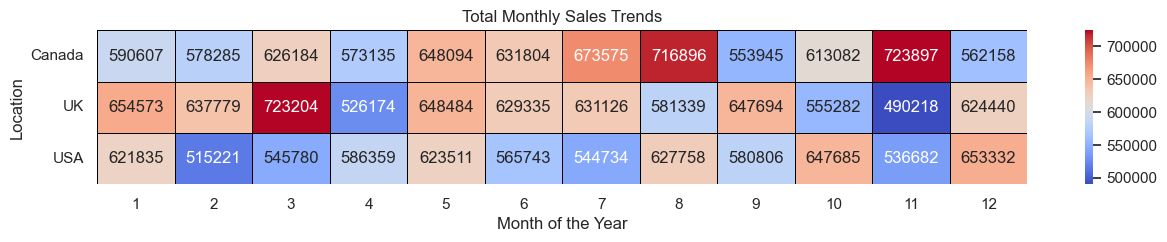

In [12]:
# Setting theme and figure size for graphs
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15, 2))

# Creating and plotting a pivot table of monthly sales per location
monthly_trends = df_full.pivot_table(index='location',
                                     columns='month',
                                     values='total_revenue',
                                     aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(monthly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Total Monthly Sales Trends')
ax.set_xlabel('Month of the Year')
ax.set_ylabel('Location')
ax.set_yticklabels(['Canada', 'UK', 'USA'], rotation=360)
plt.show()

Observation:

- Canada: Monthly sales peak at the beginning and end of spring and summer, as well as just before winter. This pattern suggests demand is influenced by seasonal and geographic factors. Harsh winter conditions and snowfall may limit outdoor activity and gym attendance, driving higher purchases during transitional seasons when people prepare for or return to regular workouts.

- United Kingdom: Sales are relatively consistent throughout the year, with the strongest spike occurring in March at the start of spring. This stability indicates a sustained cultural emphasis on fitness and health, which may support steady demand and potential long-term sales growth.

- United States: Overall sales are lower year-round compared to Canada and the UK. Demand typically spikes at the start or end of each season, with the most significant increase occurring around the New Year. This suggests strong interest in health and fitness driven by New Year’s resolutions, though demand tends to taper off quickly until it rises again in early summer.

[Back to Table of Contents](#back)

#### Geographic Annual Trends

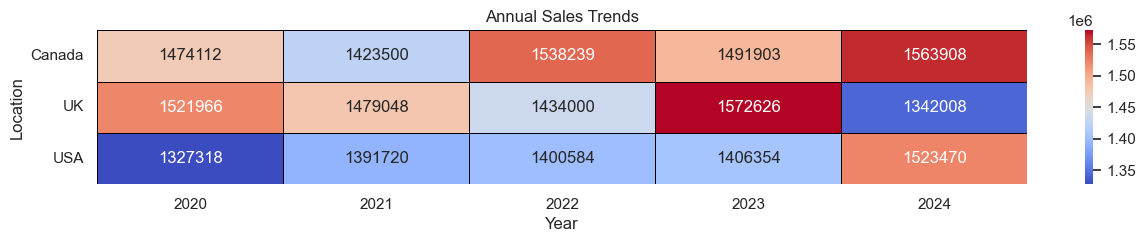

In [13]:
# Setting figure size for graphs
plt.figure(figsize=(15, 2))

# Creating and plotting a pivot table of annual total sales per location
yearly_trends = df_full.pivot_table(index='location',
                                    columns='year',
                                    values='total_revenue',
                                    aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(yearly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Annual Sales Trends')
ax.set_xlabel('Year')
ax.set_ylabel('Location')
ax.set_yticklabels(['Canada', 'UK', 'USA'], rotation=360)
plt.show()

Observation:

- Canada: Sales remained consistently strong from 2020 to 2024, reaching their highest level in 2024. This upward trend suggests a growing cultural emphasis on health and fitness, indicating Canada may represent a stable and expanding market moving forward.

- United Kingdom: Sales performance was volatile between 2020 and 2024. After a strong year in 2020, sales declined in 2021 and 2022, rebounded to a peak in 2023, and then dropped sharply in 2024 to the lowest level in the five-year period. This significant decline and inconsistency warrants further investigation to determine whether it reflects a one-time external factor or a more sustained shift in consumer behavior toward lower fitness-related spending.

- United States: The US recorded the lowest annual sales compared to Canada and the UK from 2020 through 2023. However, it is the only market to demonstrate consistent year-over-year growth across the entire period, with sales peaking in 2024. This steady increase suggests a gradual but durable shift toward a more health-conscious lifestyle, potentially signaling long-term growth potential despite currently lower overall volumes.

[Back to Table of Contents](#back)

#### Geographic Quarterly Trends

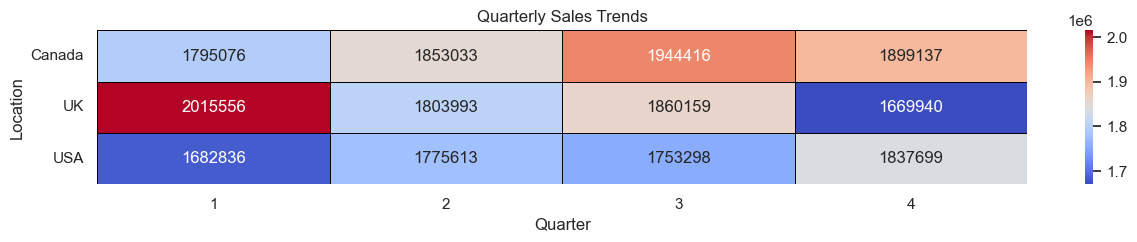

In [14]:
# Setting figure size for graphs
plt.figure(figsize=(15, 2))

# Creating and plotting a pivot table of total quarterly sales per location
quarterly_trends = df_full.pivot_table(index='location',
                                       columns='quarter',
                                       values='total_revenue',
                                       aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(quarterly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Quarterly Sales Trends')
ax.set_xlabel('Quarter')
ax.set_ylabel('Location')
ax.set_yticklabels(['Canada', 'UK', 'USA'], rotation=360)
plt.show()

Observation:

- Canada: Sales remain relatively consistent throughout the year, with the strongest performance in Q3 and the weakest in Q1. This pattern aligns with geographic and seasonal factors, as winter conditions may limit fitness activity and consumer demand early in the year.

- United Kingdom: The UK typically records its strongest sales in Q1, followed by solid performance in Q3, and the weakest results in Q4. This suggests higher demand at the beginning of the year, potentially driven by seasonal resets and renewed fitness goals.

- United States: Compared to Canada and the UK, the US shows relatively weaker sales from Q1 through Q3, with a notable peak in Q4. While this trend highlights strong year-end demand, it is based on data from 2020 to 2024, and future shifts in consumer behavior could significantly alter these seasonal patterns specifically for the US.

[Back to Table of Contents](#back)

#### Geographic Total Sales

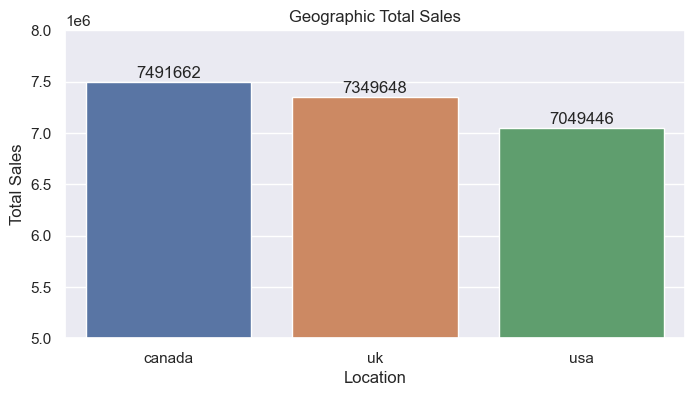

In [15]:
# Setting figure size
plt.figure(figsize=(8, 4))

# Calculating aggregate sales per location
agg_sales = df_full.groupby('location')['total_revenue'].sum().reset_index()

# Bar graph for aggregate sales by location
ax = sns.barplot(data=agg_sales,
                 x='location',
                 y='total_revenue',
                 hue='location',
                 errorbar=None)
# Creating loop to display numeric value on graph
for r in ax.patches:
    y_value = r.get_height()
    x_value = r.get_x() + r.get_width() / 2
    label = '{:.0f}'.format(y_value)
    ax.annotate(label,
                (x_value, y_value),
                xytext=(0, 1),
                textcoords='offset points',
                ha='center',
                va='bottom')
ax.set_title('Geographic Total Sales')
ax.set_xlabel('Location')
ax.set_ylabel('Total Sales')
ax.set_ylim(5000000, 8000000)

plt.show()

Observation:

- Canada is currently the largest market for nutritional supplement sales, followed by the United Kingdom, with the United States ranking third. However, these rankings may shift over time, as the US has demonstrated consistent sales growth. In addition, the US represents the largest total addressable market, and if the cultural trend toward health and fitness continues, it has the potential to outperform both Canada and the UK in the near future.

[Back to Table of Contents](#back)

#### Customer Platform Preferences

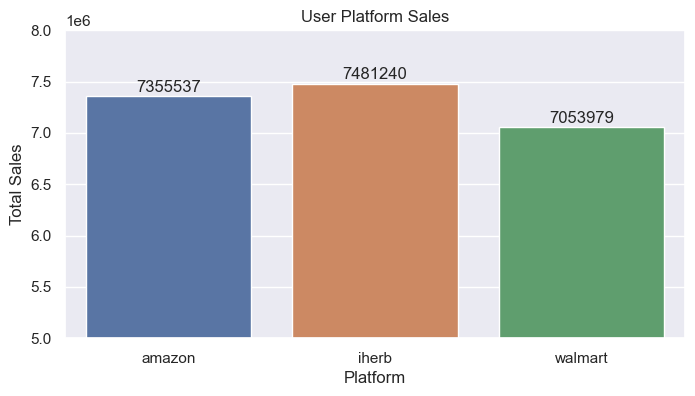

In [16]:
# Setting figure size
plt.figure(figsize=(8, 4))

# Calculating aggregate sales perh platform
agg_platform = df_full.groupby('platform')['total_revenue'].sum().reset_index()

# Bar graph for aggregate sales by platform
ax = sns.barplot(data=agg_platform,
                 x='platform',
                 y='total_revenue',
                 hue='platform',
                 errorbar=None)
# Creating loop to display numeric value on graph
for r in ax.patches:
    y_value = r.get_height()
    x_value = r.get_x() + r.get_width() / 2
    label = '{:.0f}'.format(y_value)
    ax.annotate(label,
                (x_value, y_value),
                xytext=(0, 1),
                textcoords='offset points',
                ha='center',
                va='bottom')
ax.set_title('User Platform Sales')
ax.set_xlabel('Platform')
ax.set_ylabel('Total Sales')
ax.set_ylim(5000000, 8000000)

plt.show()

Observation:

- iHerb is the primary platform customers use to purchase nutritional supplements, followed by Amazon and Walmart. This likely reflects brand positioning, as iHerb is a dedicated online marketplace focused exclusively on nutritional and wellness products. In contrast, Amazon and Walmart operate as broad, general-purpose retailers offering a wide variety of product categories, which may dilute their perceived specialization and credibility in nutrition-focused health products.

[Back to Table of Contents](#back)

### Product Performance

#### Best / Worst Product Categories by Platform

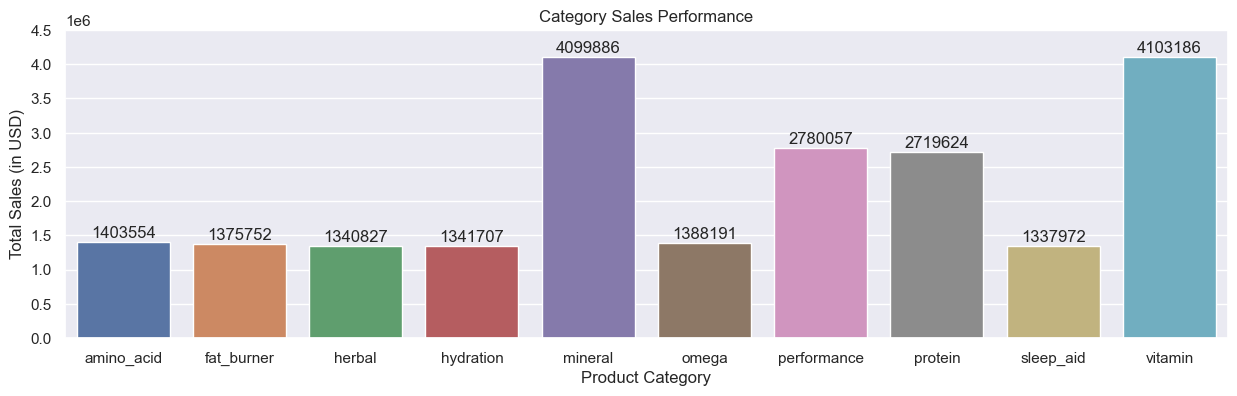

In [17]:
# Setting figure size
plt.figure(figsize=(15, 4))

# Creating aggregate sales for each category
agg_sales = df_full.groupby('category')['total_revenue'].sum().reset_index()

# Bar graph for total sales by product category
ax = sns.barplot(data=agg_sales,
                 x='category',
                 y='total_revenue',
                 hue='category',
                 errorbar=None)
# Creating loop to display numeric value on graph
for r in ax.patches:
    y_value = r.get_height()
    x_value = r.get_x() + r.get_width() / 2
    label = '{:.0f}'.format(y_value)
    ax.annotate(label,
                (x_value, y_value),
                xytext=(0, 1),
                textcoords='offset points',
                ha='center',
                va='bottom')
ax.set_title('Category Sales Performance')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Sales (in USD)')
ax.set_ylim(0, 4500000)

plt.show()

Observation:

- The top four product categories by a wide margin are Minerals, Vitamins, Performance Supplements, and Protein Supplements. Vitamins and minerals are unsurprising leaders, as they are widely consumed and easy to incorporate into daily routines even amongst individuals who are not highly health-conscious.

- It is also expected that performance and protein supplements rank next in popularity. As average people start engaging in regular gym activity, entry-level products such as pre-workout supplements and protein powders are commonly adopted, supporting demand for these categories both before and after workouts.

[Back to Table of Contents](#back)

#### Most Returns

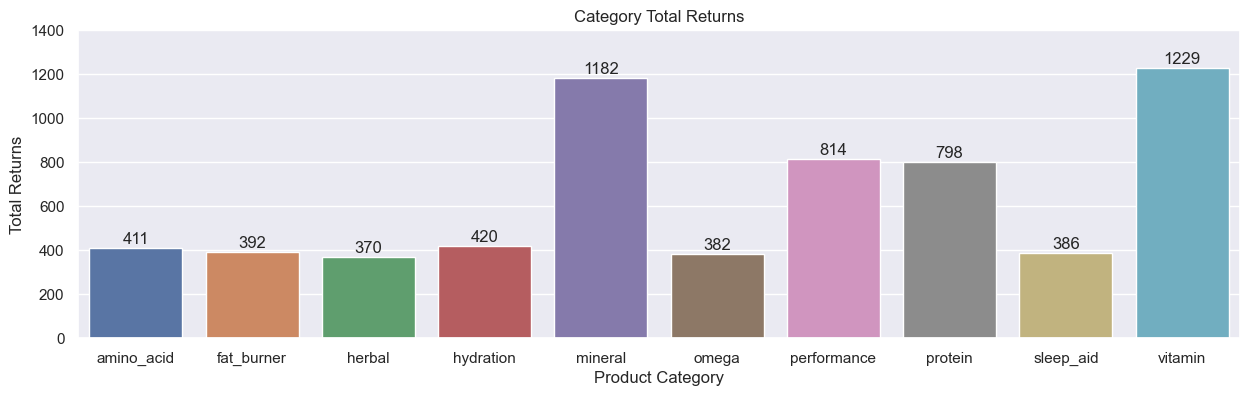

In [18]:
# Setting figure size
plt.figure(figsize=(15, 4))

# Creating aggregate returns for each category
agg_returns = df_full.groupby('category')['units_returned'].sum().reset_index()

# Bar graph for total returns by category
ax = sns.barplot(data=agg_returns,
                 x='category',
                 y='units_returned',
                 hue='category',
                 errorbar=None)
# Creating loop to display numeric value on graph
for r in ax.patches:
    y_value = r.get_height()
    x_value = r.get_x() + r.get_width() / 2
    label = '{:.0f}'.format(y_value)
    ax.annotate(label,
                (x_value, y_value),
                xytext=(0, 1),
                textcoords='offset points',
                ha='center',
                va='bottom')
ax.set_title('Category Total Returns')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Returns')
ax.set_ylim(0, 1400)

plt.show()

Observation:

- The top four returned product categories mirror the top four most sold categories: Minerals, Vitamins, Performance Supplements, and Protein Supplements

- This is not surprising, as higher sales volume naturally leads to higher return volumes within the same product categories

[Back to Table of Contents](#back)

## Conclusions and Reccomendations



[Back to Table of Contents](#back)

## Dataset Citation

Zahid Feroze. (2025, November). Supplement Sales Data, Version 1. Retrieved November 3, 2025 from [Kaggle](https://www.kaggle.com/datasets/zahidmughal2343/supplement-sales-data)

[Back to Table of Contents](#back)